![alt text](./Cerny_logo_1.jpg)

# Analysis of Cerny ventilation recordings

#### Manual revision and trimming of ventilator recordings.

This notebook imports the preprocessed **Fabian ventilator parameters** data from pickle archive for recordings `AT000001 - AT002100` and performs trimming based on manual inspection of data.

- Ventilator recordings for at least 5 minutes: **1788 cases**
- Only keep ventilator data for cases where clinical data is also available _before trimming_: **1703 cases**
- Ventilator data >=10 minutes _after_ trimming: **1673 cases**

The data processed and analysed in this Notebook were collected by the **Neonatal Emergency and Transport Service of the Peter Cerny Foundation**, Budapest, Hungary

**Author: Dr Gusztav Belteki**

### 1. Import the required libraries and set options

In [4]:
import IPython
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import os
import sys
import pickle

from pandas import Series, DataFrame
from datetime import datetime, timedelta
from matplotlib import dates

%matplotlib inline
matplotlib.style.use('classic')
matplotlib.rcParams['figure.facecolor'] = 'w'

pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)
# pd.set_option('mode.chained_assignment', None) 

import warnings
warnings.simplefilter("ignore")

In [5]:
print("Python version: {}".format(sys.version))
print("pandas version: {}".format(pd.__version__))
print("matplotlib version: {}".format(matplotlib.__version__))
print("NumPy version: {}".format(np.__version__))
print("IPython version: {}".format(IPython.__version__))

Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
pandas version: 2.2.2
matplotlib version: 3.9.2
NumPy version: 1.26.4
IPython version: 8.27.0


### 2. List and set the working directory and the directory to write out data

In [7]:
# Name of the external hard drive
DRIVE = 'GB_1'

# Directory on external drive to read the clinical from
DIR_READ = os.path.join(os.sep, 'Volumes', DRIVE, 'Ventilator_data', 'Fabian_new', 'fabian_patient_data_all_new')

# Path to project folder containing ventilation research results
PATH = os.path.join(os.sep, 'Users', 'guszti', 'Library', 'Mobile Documents', 'com~apple~CloudDocs', 
                            'Documents', 'Research', 'Ventilation')

# Folder to export the result of analysis
DIR_WRITE = os.path.join(PATH, 'ventilation_fabian_new', 'Analyses')
os.makedirs(DIR_WRITE, exist_ok = True)

# Folder on a USB stick to export data to and to import processed data exported by other Notebooks
DATA_DUMP = os.path.join(os.sep, '/Volumes', DRIVE, 'data_dump', 'fabian_new',)
os.makedirs(DATA_DUMP, exist_ok = True)

In [8]:
DIR_READ, DIR_WRITE, DATA_DUMP

('/Volumes/GB_1/Ventilator_data/Fabian_new/fabian_patient_data_all_new',
 '/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new/Analyses',
 '/Volumes/GB_1/data_dump/fabian_new')

### 3. Import pickle archives of ventilator data

In [10]:
with open(os.path.join(DATA_DUMP, 'clin_df_new.pickle'), 'rb') as handle:
    clin_df = pickle.load(handle)

with open(os.path.join(DATA_DUMP, 'data_pars_measurements_new.pickle'), 'rb') as handle:
    data_pars_measurements = pickle.load(handle)
with open(os.path.join(DATA_DUMP, 'data_pars_settings_new.pickle'), 'rb') as handle:
    data_pars_settings = pickle.load(handle)
with open(os.path.join(DATA_DUMP, 'data_pars_alarms_new.pickle'), 'rb') as handle:
    data_pars_alarms = pickle.load(handle)

In [11]:
len(data_pars_measurements)

1703

In [12]:
cases = sorted(data_pars_measurements.keys())

In [13]:
# Import DataFrame with ventilation modes before trimming
with open(os.path.join(DATA_DUMP, 'vent_modes_unedited_new.pickle'), 'rb') as handle:
    vent_modes_unedited = pickle.load(handle)
len(vent_modes_unedited)

1703

### 4. Remove the periods from the beginning and the end of the recordings when the patient was not connected to the ventilator

This requires manual inspection of the tidal volume and pressure graphs

This dictionary contains tuples of the start and end points as strings
This was obtained by manual inspection of VTmand and PIP and the recordings
and manually removing the start and the end when the baby was not on the ventilator (e.g. no VTmand)

In [16]:
with open(os.path.join(DATA_DUMP, 'limit_new_1_2100.pickle'), 'rb') as handle:
    limit = pickle.load(handle)

In [17]:
len(limit)

1703

In [18]:
from pprint import pprint
pprint(limit)

{'AT000005': ('2020-10-21 11:08:00', '2020-10-21 12:24:22'),
 'AT000006': ('2020-10-21 14:57:05', '2020-10-21 15:38:36'),
 'AT000007': ('2020-10-21 18:50:27', '2020-10-21 20:10:25'),
 'AT000008': ('2020-10-22 11:25:00', '2020-10-22 12:16:41'),
 'AT000009': ('2020-10-22 14:37:00', '2020-10-22 16:12:31'),
 'AT000011': ('2020-10-30 22:14:00', '2020-10-30 23:22:00'),
 'AT000012': ('2020-11-02 21:42:30', '2020-11-02 22:13:00'),
 'AT000013': ('2020-11-02 22:55:30', '2020-11-02 23:35:00'),
 'AT000014': ('2020-11-04 06:39:30', '2020-11-04 08:01:00'),
 'AT000015': ('2020-11-06 15:19:30', '2020-11-06 16:27:30'),
 'AT000016': ('2020-11-09 10:19:00', '2020-11-09 11:01:30'),
 'AT000017': ('2020-11-10 18:05:00', '2020-11-10 19:34:30'),
 'AT000018': ('2020-11-11 18:58:00', '2020-11-11 19:47:30'),
 'AT000019': ('2020-11-12 13:09:30', '2020-11-12 13:47:00'),
 'AT000020': ('2020-11-12 18:14:00', '2020-11-12 19:43:00'),
 'AT000022': ('2020-11-13 12:42:00', '2020-11-13 15:25:00'),
 'AT000023': ('2020-11-1

In [19]:
print(sorted(set(cases) - set(limit)))

[]


In [20]:
cases;

In [21]:
with open(os.path.join(DATA_DUMP, 'limit_new_1_2100.pickle'), 'wb') as handle:
    pickle.dump(limit, handle, protocol=pickle.HIGHEST_PROTOCOL)

### 5. Trim ventilator data using the manual filters

In [23]:
data_pars_measurements_trimmed = {}
data_pars_settings_trimmed = {}
data_pars_alarms_trimmed = {}

for case in cases:
    
    if case in limit:
        data_pars_measurements_trimmed[case] = data_pars_measurements[case][limit[case][0] : limit[case][1]]
        data_pars_settings_trimmed[case] = data_pars_settings[case][limit[case][0] : limit[case][1]]
        data_pars_alarms_trimmed[case] = data_pars_alarms[case][limit[case][0] : limit[case][1]]
        
    else:
        data_pars_measurements_trimmed[case] = data_pars_measurements[case]
        data_pars_settings_trimmed[case] = data_pars_settings[case]
        data_pars_alarms_trimmed[case] = data_pars_alarms[case]

### 6. Remove periods which stayed in some recordings when the ventilation was stopped

In [25]:
for case in data_pars_settings_trimmed:
    dta = data_pars_settings_trimmed[case]
    dta = dta[dta['Ventilation_stopped'] == 'no']
    data_pars_measurements_trimmed[case] = data_pars_measurements_trimmed[case].reindex(dta.index)
    data_pars_settings_trimmed[case] = data_pars_settings_trimmed[case].reindex(dta.index)
    data_pars_alarms_trimmed[case] = data_pars_alarms_trimmed[case].reindex(dta.index)

### 7. Exclude recordings which are shorter than 10 minutes after trimming

In [27]:
len(data_pars_measurements_trimmed), len(data_pars_settings_trimmed), len(data_pars_alarms_trimmed)

(1703, 1703, 1703)

In [28]:
# 0.5 Hz, hence 300 data points is 10 minutes
data_pars_measurements_trimmed = {case : dta for case, dta in data_pars_measurements_trimmed.items() if len(dta) >= 300}
data_pars_settings_trimmed = {case : dta for case, dta in data_pars_settings_trimmed.items() if len(dta) >= 300}
data_pars_alarms_trimmed = {case : dta for case, dta in data_pars_alarms_trimmed.items() if len(dta) >= 300}
len(data_pars_measurements_trimmed), len(data_pars_settings_trimmed), len(data_pars_alarms_trimmed)

(1673, 1673, 1673)

##### Export trimmed and cleaned DataFrames

In [30]:
%%time

with open(os.path.join(DATA_DUMP, 'data_pars_measurements_trimmed_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_measurements_trimmed, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(DATA_DUMP, 'data_pars_settings_trimmed_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_settings_trimmed, handle, protocol=pickle.HIGHEST_PROTOCOL)   
with open(os.path.join(DATA_DUMP, 'data_pars_alarms_trimmed_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_alarms_trimmed, handle, protocol=pickle.HIGHEST_PROTOCOL)

CPU times: user 1.71 s, sys: 615 ms, total: 2.33 s
Wall time: 4.14 s


### 8. Exploratory analysis on ventilation modes in the trimmed recordings

In [32]:
vent_modes_trimmed = {}
for case in data_pars_settings_trimmed:
    # Multiply by two to get the number of seconds
    vent_modes_trimmed[case] = data_pars_settings_trimmed[case]['Ventilator_mode'].value_counts() * 2
    
vent_modes_trimmed = DataFrame(vent_modes_trimmed).T
vent_modes_trimmed = vent_modes_trimmed.replace(np.nan, 0)

In [33]:
# Add the duration of the recordings
recording_duration_trimmed = {}
for case in data_pars_settings_trimmed:
    recording_duration_trimmed[case] = 2 * len(data_pars_settings_trimmed[case])

In [34]:
vent_modes_trimmed['ventilation'] = vent_modes_trimmed['IPPV']  + vent_modes_trimmed['SIMV'] + \
                                    vent_modes_trimmed['PSV']   + vent_modes_trimmed['HFO'] + \
                                    vent_modes_trimmed['SIPPV'] + vent_modes_trimmed['SIMVPSV']

vent_modes_trimmed['noninvasive'] = vent_modes_trimmed['CPAP']  + vent_modes_trimmed['DUOPAP'] + \
                                    vent_modes_trimmed['NCPAP'] + vent_modes_trimmed['O2therapy']  

vent_modes_trimmed['total'] = Series(recording_duration_trimmed)

In [35]:
# How long was VG turned on
VG = {}
for case in data_pars_settings_trimmed:
    VG[case] = sum(data_pars_settings_trimmed[case]['VG_state'] == 'on') * 2
        
VG = Series(VG)
vent_modes_trimmed['VG'] = VG

In [36]:
vent_modes_trimmed.head()

Ventilator_mode,CPAP,DUOPAP,HFO,IPPV,NCPAP,O2therapy,PSV,SIMV,SIMVPSV,SIPPV,ventilation,noninvasive,total,VG
AT000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4564.0,4564.0,0.0,4564,4538
AT000006,0.0,0.0,0.0,0.0,0.0,2492.0,0.0,0.0,0.0,0.0,0.0,2492.0,2492,0
AT000007,0.0,0.0,0.0,0.0,4800.0,0.0,0.0,0.0,0.0,0.0,0.0,4800.0,4800,0
AT000008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3102.0,0.0,0.0,3102.0,0.0,3102,3102
AT000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,650.0,0.0,4488.0,5138.0,0.0,5138,5138


In [37]:
print('SIMV:', sum(vent_modes_trimmed['SIMV'] > 0))
print('SIPPV:', sum(vent_modes_trimmed['SIPPV'] > 0))
print('SIMVPSV:', sum(vent_modes_trimmed['SIMVPSV'] > 0))
print('PSV:', sum(vent_modes_trimmed['PSV'] > 0))
print('HFO:', sum(vent_modes_trimmed['HFO'] > 0))
print('IPPV:', sum(vent_modes_trimmed['IPPV'] > 0))
print('NCPAP:', sum(vent_modes_trimmed['NCPAP'] > 0))
print('CPAP:', sum(vent_modes_trimmed['CPAP'] > 0))
print('DUOPAP:', sum(vent_modes_trimmed['DUOPAP'] > 0))
print('O2therapy:', sum(vent_modes_trimmed['O2therapy'] > 0))
print('ventilation:', sum(vent_modes_trimmed['ventilation'] > 0))
print('VG on:', sum(vent_modes_trimmed['VG'] > 0))
print('noninvasive:', sum(vent_modes_trimmed['noninvasive'] > 0))
print('total:', len(vent_modes_trimmed))

SIMV: 370
SIPPV: 382
SIMVPSV: 88
PSV: 7
HFO: 136
IPPV: 16
NCPAP: 718
CPAP: 47
DUOPAP: 161
O2therapy: 177
ventilation: 801
VG on: 658
noninvasive: 985
total: 1673


In [38]:
# How many seconds of each ventilation mode in total ?
total_duration_trimmed = DataFrame(vent_modes_trimmed.sum(axis = 0), columns = ['duration (seconds)'])
total_duration_trimmed

,duration (seconds)
Ventilator_mode,
CPAP,11402.0
DUOPAP,445756.0
HFO,481686.0
IPPV,21234.0
NCPAP,2133836.0
O2therapy,539482.0
PSV,12804.0
SIMV,1315384.0
SIMVPSV,254654.0


#### Export Dataframes containing ventilator modes to Excel files and pickle archives

In [40]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'ventilation_modes_trimmed_new.xlsx'))
vent_modes_trimmed.to_excel(writer, sheet_name='vent_modes')
total_duration_trimmed.to_excel(writer, sheet_name='total_duration')
writer.close()

In [41]:
with open(os.path.join(DATA_DUMP, 'vent_modes_trimmed_new.pickle'), 'wb') as handle:
    pickle.dump(vent_modes_trimmed, handle, protocol=pickle.HIGHEST_PROTOCOL)

### 9. Export text files with the clinical data of the trimmed recordings

In [43]:
%%time

for case in data_pars_settings_trimmed:
    a = data_pars_settings_trimmed[case]
    
    o2therapy = len(a[a['Ventilator_mode'] == 'O2therapy'])
    ncpap = len(a[a['Ventilator_mode'] == 'NCPAP'])
    duopap = len(a[a['Ventilator_mode'] == 'DUOPAP'])
    simv = len(a[a['Ventilator_mode'] == 'SIMV'])
    ippv = len(a[a['Ventilator_mode'] == 'IPPV'])
    sippv = len(a[a['Ventilator_mode'] == 'SIPPV'])
    simvpsv = len(a[a['Ventilator_mode'] == 'SIMVPSV'])
    psv = len(a[a['Ventilator_mode'] == 'PSV'])
    hfo = len(a[a['Ventilator_mode'] == 'HFO'])
    vg_on = len(a[a['VG_state'] == 'on'])
  
    fileout = open(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_vent_info_trimmed.txt'), 'w')
    
    fileout.write('O2 therapy: %d sec \n' % (o2therapy * 2))
    fileout.write('NCPAP:      %d sec \n' % (ncpap * 2))
    fileout.write('DUOPAP:     %d sec \n' % (duopap * 2))
    fileout.write('IPPV:       %d sec \n' % (ippv * 2))
    fileout.write('SIPPV:      %d sec \n' % (sippv * 2))
    fileout.write('SIMV:       %d sec \n' % (simv * 2))
    fileout.write('SIMVPSV:    %d sec \n\n' % (simvpsv * 2))
    fileout.write('PSV:        %d sec \n\n' % (psv * 2))
    fileout.write('HFO:        %d sec \n\n' % (hfo * 2))
    fileout.write('VG on:      %d sec \n' % (vg_on * 2))
    
    fileout.close()

CPU times: user 4.14 s, sys: 287 ms, total: 4.42 s
Wall time: 6.9 s


### 10. Export graphs with the ventilation  modes of the trimmed recordings ventilator modes

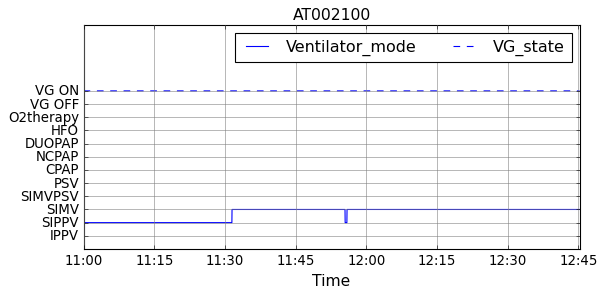

Generated graphs for 1673 recordings. 

CPU times: user 5min 23s, sys: 4.8 s, total: 5min 28s
Wall time: 1min 53s


In [45]:
%%time

mapping_vent_mode = {1: 'IPPV', 2: 'SIPPV', 3: 'SIMV', 4: 'SIMVPSV', 5: 'PSV', 6: 'CPAP', 7: 'NCPAP', 8: 'DUOPAP', 
                     9: 'HFO', 10: 'O2therapy'}
mapping_vent_mode_rev = {value:key for key, value in mapping_vent_mode.items()}
mapping_vent_mode_rev

mapping_VG = {11: 'off', 12: 'on'}
mapping_VG_rev = {value:key for key, value in mapping_VG.items()}
mapping_VG_rev

par1 = 'Ventilator_mode'; par2 = 'VG_state'
dim = 'cmH$_2$O'; filetype='jpg'; dpi=200
yticks = np.arange(1, 13)
yticklabels = ['IPPV', 'SIPPV','SIMV','SIMVPSV', 'PSV', 'CPAP', 'NCPAP', 'DUOPAP', 'HFO', 'O2therapy', 'VG OFF', 'VG ON']
n=0

for case in data_pars_settings_trimmed:
    
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    ax = fig.add_subplot(1, 1, 1)
        
    data = data_pars_settings_trimmed[case][par1].replace(mapping_vent_mode_rev).dropna().astype('int')
    data.plot(ax = ax, label = par1, color='blue', x_compat = True)
        
    data_2 = data_pars_settings_trimmed[case][par2].replace(mapping_VG_rev).dropna().astype('int')
    data_2.plot(ax = ax, label = par2, color='blue', linestyle='dashed', x_compat = True)
        
    ax.set_xlabel('Time', size = 14, color = 'black')
    ax.set_ylabel('', size = 14, color = 'black')
    ax.set_ylim(0,17)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.set_title(case,  size = 14, color = 'black')
    ax.legend(ncols=2)
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    majorFmt = dates.DateFormatter('%H:%M')
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
    
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_trimmed_ventilation_mode.{filetype}'), 
        dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != cases[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')